## Time to get your hands dirty. Galaxies vs quasars with neural networks.

Let's go back to our galaxy vs quasar data we've used in a previous exercise. 

1. Read in SDSS galaxy color data from `solutions/galaxyquasar.csv`. Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 

2. Now we're going to fit a neural network classifier. First, scale your data appropriately and do a 30% train/test split.

3. Now train the classifier. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

3. Start from a network architecture with a single hidden layer with 5 neurons, using the `adam` solver, the `relu` activation function, and a learninig rate of `0.001`. Plot the resulting ROC curve. 

4. Now let's optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

5. Is your best result comparable with the simpler classifiers we've seen before? Do we need deep learning here? If yes, which features are captured best?


A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
labels = ['u', 'g','r','i', 'z' ]
filters = []
for i in range(len(labels)-1):
    filters.append(data[labels[i]]-data[labels[i+1]])
filters = np.array(filters)
filters.shape

(4, 50000)

In [5]:
classes = np.zeros(len(data['class']))
for i in range(len(data['class'])):
    if data['class'][i] == 'QSO':
        classes[i] = 1.0
classes

array([1., 0., 0., ..., 0., 0., 0.])

In [6]:
data_mean = np.mean(filters, axis = 1, keepdims=True)
data_std = np.std(filters, axis = 1, keepdims=True)
scaled_data = (filters - data_mean)/data_std

In [7]:
X = scaled_data.T
X.shape

(50000, 4)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, classes, train_size=0.70, test_size=0.30)
X_train.shape


(35000, 4)

In [9]:
import tensorflow as tf
import keras

2026-01-09 12:55:46.707481: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
model = keras.models.Sequential([
    keras.layers.Dense(units=5, input_shape=(4,) , activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
    ])

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
clf = model.fit(X_train, y_train)

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8928 - loss: 0.3215


In [12]:
y_pred = model.predict(X_test)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


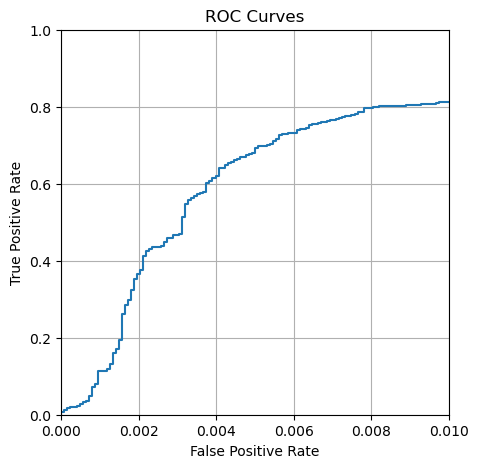

In [13]:
from sklearn.metrics import roc_curve as ROC

fpr, tpr, th = ROC(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0, 0.01)
plt.ylim(0,1)
plt.grid(True)

In [14]:
from astroML.utils import completeness_contamination
y_lab = (y_pred > 0.5).astype(int).flatten()
compl, contam = completeness_contamination(y_test, y_lab)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.918
Contamination = 0.175


This is alredy way better than what we did last time! 

Let's try to optimize the hyperparameters of our network.

In [15]:
###Learning how to use tensorboard###
import datetime
%load_ext tensorboard

bttr_model = keras.models.Sequential([
        keras.layers.Dense(units=7, input_shape=(4,) , activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        ])

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
bttr_model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

bttr_model.fit(X_train, y_train, epochs=5, validation_split=0.2, callbacks=[tensorboard_callback])

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9800 - loss: 0.1019 - val_accuracy: 0.9797 - val_loss: 0.0839
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9822 - loss: 0.0773 - val_accuracy: 0.9789 - val_loss: 0.0812
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9822 - loss: 0.0786 - val_accuracy: 0.9769 - val_loss: 0.0824
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9828 - loss: 0.0772 - val_accuracy: 0.9821 - val_loss: 0.0800
Epoch 5/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9834 - loss: 0.0719 - val_accuracy: 0.9833 - val_loss: 0.0723


In [17]:
%tensorboard --logdir logs/fit

In [18]:
### Optimizing the hyperparams ###

from tensorboard.plugins.hparams import api as hp
from keras.optimizers import Adam, SGD

HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([4, 7, 10]))
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd']))
HP_LRATE = hp.HParam('learning_rate', hp.Discrete([0.002, 0.02, 0.2]))

METRIC_ACCURACY = 'accuracy'

with tf.summary.create_file_writer('logs/hparam_tuning').as_default():
  hp.hparams_config(
    hparams=[HP_NUM_UNITS, HP_OPTIMIZER, HP_LRATE],
    metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
  )

In [19]:
def train_test_model(hparams):
    model = keras.models.Sequential([
        keras.layers.Dense(hparams[HP_NUM_UNITS], input_shape=(4,) , activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        ])

    if hparams[HP_OPTIMIZER] == 'adam':
        opt = keras.optimizers.Adam(learning_rate=hparams[HP_LRATE])
    elif hparams[HP_OPTIMIZER] == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=hparams[HP_LRATE])
    else:
        raise ValueError(f"Unknown optimizer: {hparams[HP_OPTIMIZER]}")
    model.compile(
      optimizer=opt,
      loss="binary_crossentropy",
      metrics=['accuracy'])
    
    model.fit(X_train, y_train, epochs=1) # Run with 1 epoch to speed things up for demo purposes
    _, accuracy = model.evaluate(X_test, y_test)
    return accuracy

In [20]:
def run(run_dir, hparams):
  with tf.summary.create_file_writer(run_dir).as_default():
    hp.hparams(hparams)  # record the values used in this trial
    accuracy = train_test_model(hparams)
    tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

In [21]:
session_num = 0

for num_units in HP_NUM_UNITS.domain.values:
    for optimizer in HP_OPTIMIZER.domain.values:
        for lrate in HP_LRATE.domain.values:
          hparams = {
              HP_NUM_UNITS: num_units,
              HP_OPTIMIZER: optimizer,
              HP_LRATE: lrate,
          }
          run_name = "run-%d" % session_num
          print('--- Starting trial: %s' % run_name)
          print({h.name: hparams[h] for h in hparams})
          run('logs/hparam_tuning/' + run_name, hparams)
          session_num += 1

--- Starting trial: run-0
{'num_units': 4, 'optimizer': 'adam', 'learning_rate': 0.002}


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9474 - loss: 0.2101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0869
--- Starting trial: run-1
{'num_units': 4, 'optimizer': 'adam', 'learning_rate': 0.02}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9777 - loss: 0.0968
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9830 - loss: 0.0747
--- Starting trial: run-2
{'num_units': 4, 'optimizer': 'adam', 'learning_rate': 0.2}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9739 - loss: 0.1409
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0800
--- Starting trial: run-3
{'num_units': 4, 'optimizer': 'sgd', 'learning_rate': 0.002}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7744 - loss: 0.5981
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9581 - loss: 0.4353
--- Starting trial: run-4
{'num_units': 4, 'optimizer': 'sgd', 'learning_rate': 0.02}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - a

In [22]:
%tensorboard --logdir logs/hparam_tuning

So our best models (higher accuracy) are:

- num_units = 10, opt = adam, lr = 0.02
- num_units = 4, opt = adam, lr = 0.02
- num_units = 7, opt = sgd, lr = 0.20


In [23]:
model_1 = keras.models.Sequential([
        keras.layers.Dense(units=10, input_shape=(4,) , activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        ])
optimizer = keras.optimizers.Adam(learning_rate=0.02)
model_1.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
fpr_1, tpr_1, _ = ROC(y_test, y_pred_1)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9801 - loss: 0.0905
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
model_2 =  keras.models.Sequential([
        keras.layers.Dense(units=4, input_shape=(4,) , activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        ])
optimizer = keras.optimizers.Adam(learning_rate=0.02)
model_2.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
fpr_2, tpr_2, _ = ROC(y_test, y_pred_2)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9734 - loss: 0.1042
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
model_3 =  keras.models.Sequential([
        keras.layers.Dense(units=7, input_shape=(4,) , activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        ])
optimizer = keras.optimizers.SGD(learning_rate=0.20)
model_3.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)
fpr_3, tpr_3, _ = ROC(y_test, y_pred_3)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9791 - loss: 0.0966
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


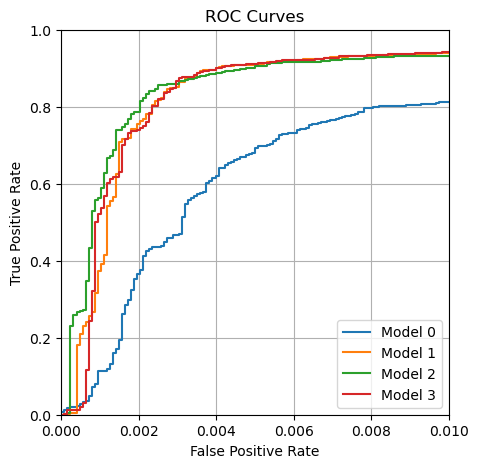

In [26]:
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label = 'Model 0')
plt.plot(fpr_1, tpr_1, label = 'Model 1')
plt.plot(fpr_2, tpr_2, label = 'Model 2')
plt.plot(fpr_3, tpr_3, label = 'Model 3')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0, 0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)

Model 2 is our final choice! 

In [27]:
y_lab = (y_pred_2 > 0.5).astype(int).flatten()
compl, contam = completeness_contamination(y_test, y_lab)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.968
Contamination = 0.095


In [28]:
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f'Loss = {loss:.3f}')
print(f'Accuracy = {accuracy:.3f}')

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9831 - loss: 0.0740
Loss = 0.074
Accuracy = 0.983
